In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

pd.set_option('display.max_columns', 50)
print('All imports successful.')

All imports successful.


In [3]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Basic Info & Data Types

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


Handle Missing Values

TotalCharges is read as object(string) because it contains whitespace for new customers (tenure=0).Convert it to float, which turns whitespace into NaN,then Impute

In [6]:
# Fix TotalCharges dtype
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

              Missing Count  Missing %
TotalCharges             11   0.156183


In [7]:
# For new customers (tenure=0), TotalCharges should logically be 0
# Impute with median for safety
median_tc = df['TotalCharges'].median()
df['TotalCharges'].fillna(median_tc, inplace=True)

print(f'Missing values after imputation: {df.isnull().sum().sum()}')

Missing values after imputation: 0


Handle Duplicates

In [8]:
duplicate_count = df.duplicated().sum()
print(f'Duplicate rows: {duplicate_count}')

if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print(f'Duplicates removed. New shape: {df.shape}')
else:
    print('No duplicates found.')

Duplicate rows: 0
No duplicates found.


Handle Outliners

Using IQR method on numerical columns to detect, then cap(winsorize) rather than drop.

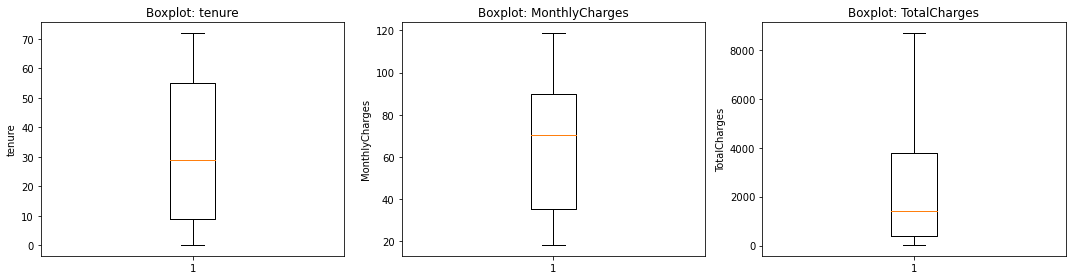

In [9]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(f'Boxplot: {col}')
    axes[i].set_ylabel(col)
plt.tight_layout()
plt.show()


In [10]:
def cap_outliers_iqr(df, col):
    """Cap outliers at 1.5*IQR (Winsorization)."""
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f'{col}: {outliers} outliers capped (lower={lower:.2f}, upper={upper:.2f})')
    return df

for col in numerical_cols:
    df = cap_outliers_iqr(df, col)

tenure: 0 outliers capped (lower=-60.00, upper=124.00)
MonthlyCharges: 0 outliers capped (lower=-46.02, upper=171.38)
TotalCharges: 0 outliers capped (lower=-4674.34, upper=8863.16)


Drop Irrelevant Columns

In [ ]:
# customerID is a unique identifier — not a predictive feature
df.drop(columns=['customerID'], inplace=True)
print(f'Shape after dropping customerID: {df.shape}')

 Encode Categorical Variables

Strategy:
- Binary columns (Yes/No, Male/Female): Label Encoding (0/1)
- Multi-class columns (InternetService, Contract, PaymentMethod): One-Hot Encoding
- Target column(`Churn`): Label Encoding separately

In [11]:
# Identify column types
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', cat_cols)

# Separate target
target = 'Churn'
cat_cols_features = [c for c in cat_cols if c != target]

Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [12]:
# Identify binary vs multi-class
binary_cols = [c for c in cat_cols_features if df[c].nunique() == 2]
multiclass_cols = [c for c in cat_cols_features if df[c].nunique() > 2]

print('Binary cols (Label Encode):', binary_cols)
print('Multi-class cols (One-Hot Encode):', multiclass_cols)

Binary cols (Label Encode): ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Multi-class cols (One-Hot Encode): ['customerID', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [13]:
# Label Encode binary columns
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# Label Encode target
df[target] = le.fit_transform(df[target])  # Yes=1, No=0
print(f'Churn value counts after encoding:\n{df[target].value_counts()}')

Churn value counts after encoding:
0    5174
1    1869
Name: Churn, dtype: int64


In [14]:
# One-Hot Encode multi-class columns
df = pd.get_dummies(df, columns=multiclass_cols, drop_first=True)
print(f'Shape after One-Hot Encoding: {df.shape}')
df.head()

Shape after One-Hot Encoding: (7043, 7073)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,customerID_0014-BMAQU,customerID_0015-UOCOJ,customerID_0016-QLJIS,customerID_0017-DINOC,customerID_0017-IUDMW,customerID_0018-NYROU,customerID_0019-EFAEP,customerID_0019-GFNTW,customerID_0020-INWCK,...,customerID_9992-RRAMN,customerID_9992-UJOEL,customerID_9993-LHIEB,customerID_9995-HOTOH,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


Scale Numerical Featutres

Using StandardScaler for distance-based models (Logistic Regression, SVM). We keep an unscaled copy for tree-based models.

In [15]:
# Separate features and target
X = df.drop(columns=[target])
y = df[target]

# Scale numerical columns
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numerical_cols] = scaler.fit_transform(X[numerical_cols])

print('Scaling complete. Sample of scaled numerical features:')
print(X_scaled[numerical_cols].describe().round(3))

Scaling complete. Sample of scaled numerical features:
         tenure  MonthlyCharges  TotalCharges
count  7043.000        7043.000      7043.000
mean      0.000          -0.000         0.000
std       1.000           1.000         1.000
min      -1.318          -1.546        -0.999
25%      -0.952          -0.973        -0.830
50%      -0.137           0.186        -0.390
75%       0.921           0.834         0.664
max       1.614           1.794         2.827


Saved Preprocessed Data

In [16]:
# Save unscaled (for tree-based models)
X.assign(Churn=y).to_csv('telco_preprocessed.csv', index=False)

# Save scaled (for distance-based models)
X_scaled.assign(Churn=y).to_csv('telco_preprocessed_scaled.csv', index=False)

print(f'Saved telco_preprocessed.csv — shape: {X.shape}')
print(f'Saved telco_preprocessed_scaled.csv — shape: {X_scaled.shape}')


Saved telco_preprocessed.csv — shape: (7043, 7072)
Saved telco_preprocessed_scaled.csv — shape: (7043, 7072)


In [18]:
df.to_csv("telco_cleaned.csv", index=False)